# Survival Analysis of Post-RARP Outcomes and PSA Threshold Assessment

This notebook presents a time-to-event analysis of patients undergoing 
Robot-Assisted Radical Prostatectomy (RARP), with a focus on biochemical recurrence 
and response to Fincar therapy.

> **Data Availability Notice**  
> This analysis is based on a retrospective clinical dataset that cannot be shared 
> publicly due to patient privacy and ethical restrictions.  
> The notebook demonstrates analytical methodology, statistical reasoning, and 
> interpretation.


In [4]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df.shape

(193, 130)

In [7]:
print("Number of columns:", len(df.columns))
print(df.columns.tolist())

Number of columns: 130
['UHID', 'Age', 'Date of Surgery', 'Date of Dischrge', 'Length of Stay', 'Height in cm', 'Weight in kg', 'BMI (F)', 'BMI', 'Comorbidities', 'DRE', 'Clinical Stage', 'D AMICO Risk', 'TURP/HOLEP-Yes/Nil ', 'Pre OP Hormone Treatment', 'Pre Op-USG', 'Pre Op-MRI', 'Pre-OP PSMA PET Scan', 'PSMA Avid Node or Mets positivity on Scan', 'SUV MAX Value', 'Biopsy Remark By PI', 'Gleason Score in Pre-OP Biopsy ', 'No. of Cores Right', 'No. of Cores Left', 'Total No. of Positive Cores', 'Maximum Percentage of Cores', 'Robot', 'Console - Start Time', 'Console - End Time', 'Console Time in hrs', 'Console Time in Minutes(For)', 'Console Time in Minutes', 'Bladder Neck Sparing', 'Rocco', 'PDS versus V loc', 'Suspension', 'Conventional', 'Retzius Sparing', 'Detrussor Apron Preservation 1/2/3', 'Interfascial/ Intrafascial/ Extrafascial', 'Nerve Sparing', 'Median Lobe', 'Lymph Node', 'Peritoneal Incision Open/Closed', 'Hemoststic Agent', 'Specimen Inked-Yes/No', ' Intra OP-Complicati

## Objective

To evaluate time-to-event outcomes following RARP and to assess whether 
pre-treatment PSA levels are associated with response to Fincar therapy using 
Kaplan–Meier survival analysis and ROC–AUC–based threshold assessment.


# Define ST

## Outcome and Censoring Definition

The primary outcome was treatment failure following Fincar administration, defined 
as biochemical recurrence requiring further intervention.

Time-to-event was defined as the duration (in months) from the date of Fincar 
administration to documented failure. Patients without failure at last follow-up 
were treated as censored observations.


In [9]:
# Create survival_time
from datetime import datetime


today = datetime.today()

df['Failure Duration (Month)'] = pd.to_numeric(df['Failure Durarion (Month)'], errors='coerce')

# Create survival_time
df['survival_time'] = df.apply(
    lambda row: row['Failure Duration (Month)']
    if row['Fincar Result'] == 'Failure'
    else (today - row['Date of Fincar Administration']).days // 30
    if pd.notnull(row['Date of Fincar Administration']) else None,
    axis=1
)






## Kaplan–Meier Survival Analysis

Kaplan–Meier survival curves were used to visualize time-to-event distributions. 
Survival probability represents the likelihood of remaining failure-free over time. 
Group differences were assessed using the log-rank test.


In [10]:
#  Define event: 1 for failure, 0 for success, 0 for censored cases
df['event'] = df['Fincar Result'].apply(lambda x: 1 if x == 'Failure' else 0)


In [11]:
# Check unique values and data format
print("Unique values in 'Fincar Administrated':")
print(df['Fincar Administrated'].unique())

print("\nValue counts for 'event':")
print(df['event'].value_counts())

print("\nSummary statistics for 'survival_time':")
print(df['survival_time'].describe())


Unique values in 'Fincar Administrated':
['Yes' '\xa0Ye' 'Ye']

Value counts for 'event':
event
0    127
1     66
Name: count, dtype: int64

Summary statistics for 'survival_time':
count    185.000000
mean      15.005405
std        8.901940
min        1.000000
25%        9.000000
50%       14.000000
75%       21.000000
max       70.000000
Name: survival_time, dtype: float64


In [12]:
# Clean and filter

df['Fincar Administrated'] = df['Fincar Administrated'].str.strip().replace({'\xa0Ye': 'Yes', 'Ye': 'Yes'})

df = df[df['survival_time'].notnull() & (df['survival_time'] >= 0)]

df = df[df['event'].notnull()]

print("Cleaned dataset shape:", df.shape)



Cleaned dataset shape: (185, 133)


In [13]:
# Check how many events (failures) we have
print(df['event'].value_counts())

event
0    124
1     61
Name: count, dtype: int64


### Overall Survival

The overall Kaplan–Meier curve demonstrates the distribution of failure-free survival 
time following Fincar administration across the study cohort.


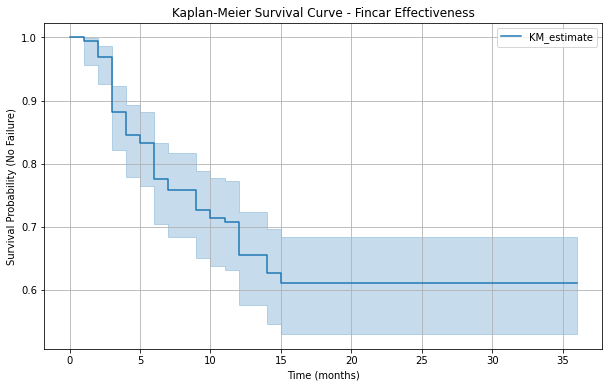

In [59]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Initialize Kaplan-Meier model
kmf = KaplanMeierFitter()

kmf.fit(durations=df['survival_time'], event_observed=df['event'])

plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve - Fincar Effectiveness")
plt.xlabel("Time (months)")
plt.ylabel("Survival Probability (No Failure)")
plt.grid(True)
plt.show()


1. Initial Drop is steep: Most failures occur in the early phase
2. Survival rate plateaus after 20 days which indicates that patients surviving the initial phase, are most likely to have longer survival
3. Rate Stabilizes around 0.6 i.e Around 60% patients have longer survival time


In [16]:
df['Gleason score (HPR)'].value_counts(dropna=False)

Gleason score (HPR)
3+4            67
4+3            43
4+5            30
4+4            13
3+3            10
3+5             4
4+3=7           4
4+4=8           3
3+4=7           3
3+3=6           2
NM              1
5+4             1
5+4 = 9/10      1
3 + 4= 7/10     1
4 + 3 = 7       1
 4+5 = 10       1
Name: count, dtype: int64

In [17]:
# Replace inconsistent formatting in 'Gleason score (HPR)'
df['Gleason score (HPR)'] = df['Gleason score (HPR)'].str.strip()

# Mapping different versions to consistent categories
gleason_mapping = {
    '3+3': '3+3',
    '3+3=6': '3+3',
    '3+4': '3+4',
    '3+4=7': '3+4',
    '3 + 4= 7/10': '3+4',
    '4+3': '4+3',
    '4+3=7': '4+3',
    '4 + 3 = 7': '4+3',
    '4+4': '4+4',
    '4+4=8': '4+4',
    '3+5': '3+5',
    '4+5': '4+5',
    '4+5 = 10': '4+5',
    '5+4 = 9/10': '5+4'
}

df['Gleason_cleaned'] = df['Gleason score (HPR)'].map(gleason_mapping)


### Survival Stratified by Gleason Score

Survival curves were stratified by post-operative Gleason score to explore the 
relationship between pathological risk and time-to-event outcomes.


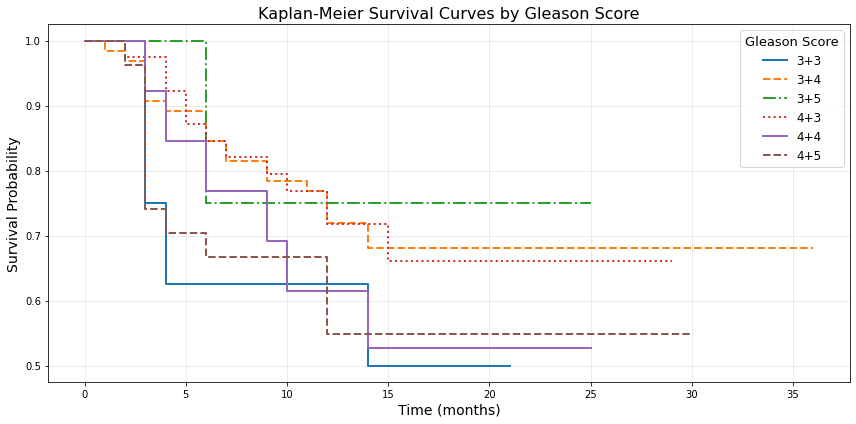

In [60]:
# Filter relevant rows
gleason_data = df[['survival_time', 'event', 'Gleason_cleaned']].dropna()

plt.figure(figsize=(12, 6))
kmf = KaplanMeierFitter()

# Use a consistent color palette
colors = plt.cm.tab10.colors  # 10 nice colors from matplotlib
line_styles = ['-', '--', '-.', ':', '-', '--']  # cycle styles if needed

for i, group in enumerate(sorted(gleason_data['Gleason_cleaned'].unique())):
    mask = gleason_data['Gleason_cleaned'] == group
    kmf.fit(gleason_data[mask]['survival_time'],
            gleason_data[mask]['event'],
            label=str(group))
    kmf.plot_survival_function(
        ci_show=False, 
        color=colors[i % len(colors)], 
        linestyle=line_styles[i % len(line_styles)],
        linewidth=2
    )

plt.title('Kaplan-Meier Survival Curves by Gleason Score', fontsize=16)
plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival Probability', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(title='Gleason Score', fontsize=12, title_fontsize=13)
plt.tight_layout()
plt.show()


In [19]:
from lifelines.statistics import multivariate_logrank_test

results = multivariate_logrank_test(
    df['survival_time'],
    df['Gleason_cleaned'],
    df['event']
)

print(results.summary)

   test_statistic         p  -log2(p)
0        2.750299  0.839471  0.252448


In [20]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import pandas as pd

# SClean the event and censoring labels
df['event'] = df['Fincar Result'].map({
    'Success': 0,            # No event 
    'Failure': 1,            # Event occurred
    'NFU': 0,                # Censored (not followed up)
    'Recently Given': 0     # Censored (too early to judge)
})

# Mark censoring status (True = observed event, False = censored)
df['observed'] = df['Fincar Result'].map({
    'Success': True,
    'Failure': True,
    'NFU': False,
    'Recently Given': False
})


In [22]:
from lifelines.statistics import logrank_test

group_success = df[df["Fincar Result"] == "Success"]
group_failure = df[df["Fincar Result"] == "Failure"]

# log-rank test
results = logrank_test(
    group_success["survival_time"], 
    group_failure["survival_time"], 
    event_observed_A=group_success["event"], 
    event_observed_B=group_failure["event"]
)

print(f"Log-rank test p-value: {results.p_value}")


Log-rank test p-value: 1.589964967866736e-48


### Survival by Fincar Outcome

Kaplan–Meier curves comparing patients with Fincar success and failure illustrate 
differences in failure-free survival between outcome groups.


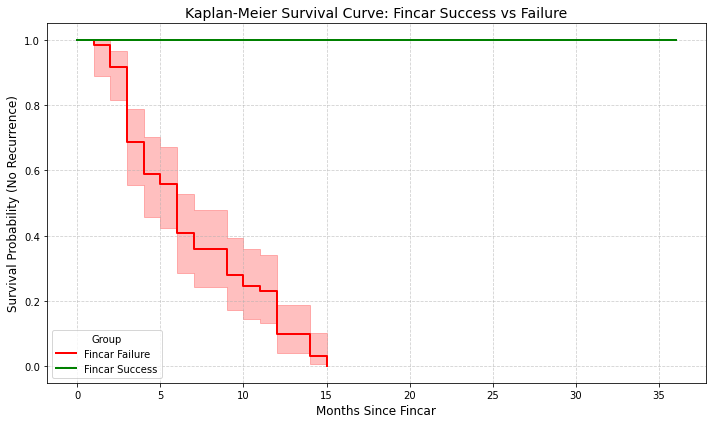

In [23]:

from lifelines import KaplanMeierFitter

# Filter dataset to include only 'Success' and 'Failure'
df_filtered = df[df['Fincar Result'].isin(['Success', 'Failure'])].copy()

df_filtered['group'] = df_filtered['Fincar Result'].map({'Success': 'Fincar Success', 'Failure': 'Fincar Failure'})

plt.figure(figsize=(10, 6))
colors = {'Fincar Success': 'green', 'Fincar Failure': 'red'}

kmf = KaplanMeierFitter()
for label, group_df in df_filtered.groupby('group'):
    kmf.fit(group_df['survival_time'], event_observed=group_df['event'], label=label)
    kmf.plot(ci_show=True, linewidth=2, color=colors[label])

plt.title('Kaplan-Meier Survival Curve: Fincar Success vs Failure', fontsize=14)
plt.xlabel('Months Since Fincar', fontsize=12)
plt.ylabel('Survival Probability (No Recurrence)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Group')
plt.tight_layout()
plt.show()


1. Median survival probability (50%) was reached at around 6–7 months.
2. All patients experienced reccurence by 15 months

In [25]:
# Median survival time (failure-free duration)
median_survival = kmf.median_survival_time_
print("Median survival time (in months):", median_survival)


Median survival time (in months): inf


# # T-test/Mann-Whitney

In [29]:
from scipy.stats import ttest_ind, mannwhitneyu

In [30]:
success = df[df['Fincar Result'] == 'Success']
failure = df[df['Fincar Result'] == 'Failure']

In [32]:
# T-tests
t_tumor = ttest_ind(success['Volume of Tumour-Right'].dropna(), failure['Volume of Tumour-Right'].dropna())
t_prostate = ttest_ind(success['Volume of Prostate in gms'].dropna(), failure['Volume of Prostate in gms'].dropna())
t_console = ttest_ind(success['Console Time in Minutes'].dropna(), failure['Console Time in Minutes'].dropna())
t_age = ttest_ind(success['Age'].dropna(), failure['Age'].dropna())
t_psa=ttest_ind(success['PSA before fincar '].dropna(),failure['PSA before fincar '].dropna())

In [33]:
print("T-test Results:")
print("Tumor Volume:", t_tumor)
print("Prostate Volume:", t_prostate)
print("Console Time:", t_console)
print("Age:", t_age)
print("PSA before Fincar:",t_psa)


T-test Results:
Tumor Volume: TtestResult(statistic=-1.5599730387762005, pvalue=0.21667136130990136, df=3.0)
Prostate Volume: TtestResult(statistic=-0.4931380805014034, pvalue=0.6225997176438722, df=158.0)
Console Time: TtestResult(statistic=-0.7847246014232587, pvalue=0.4337900531532757, df=158.0)
Age: TtestResult(statistic=0.8451668699826539, pvalue=0.3992876713335952, df=159.0)
PSA before Fincar: TtestResult(statistic=-4.923310116163098, pvalue=2.1123578331636964e-06, df=159.0)


In [34]:
# Mann-Whitney U tests
u_tumor = mannwhitneyu(success['Volume of Tumour-Right'].dropna(), failure['Volume of Tumour-Right'].dropna(), alternative='two-sided')
u_prostate = mannwhitneyu(success['Volume of Prostate in gms'].dropna(), failure['Volume of Prostate in gms'].dropna(), alternative='two-sided')
u_console = mannwhitneyu(success['Console Time in Minutes'].dropna(), failure['Console Time in Minutes'].dropna(), alternative='two-sided')
u_age = mannwhitneyu(success['Age'].dropna(), failure['Age'].dropna(), alternative='two-sided')
u_psa=mannwhitneyu(success['PSA before fincar '].dropna(),failure['PSA before fincar '].dropna(), alternative='two-sided')

In [35]:
print("\nMann-Whitney U Test Results:")
print("Tumor Volume:", u_tumor)
print("Prostate Volume:", u_prostate)
print("Console Time:", u_console)
print("Age:", u_age)
print("PSA before Fincar:", u_psa)


Mann-Whitney U Test Results:
Tumor Volume: MannwhitneyuResult(statistic=1.0, pvalue=0.4)
Prostate Volume: MannwhitneyuResult(statistic=2527.5, pvalue=0.08413891074119759)
Console Time: MannwhitneyuResult(statistic=2768.0, pvalue=0.3778230538229871)
Age: MannwhitneyuResult(statistic=3320.0, pvalue=0.3470531931128179)
PSA before Fincar: MannwhitneyuResult(statistic=1833.0, pvalue=2.231009182744152e-05)


## PSA Threshold Analysis Using ROC–AUC

Receiver Operating Characteristic (ROC) analysis was performed to evaluate the 
ability of pre-treatment PSA levels to discriminate between Fincar success and 
failure.

The optimal PSA threshold was identified using the Youden Index, balancing 
sensitivity and specificity.


In [36]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np



Optimal PSA Threshold: 0.051
Sensitivity (TPR): 0.57
Specificity (1 - FPR): 0.78
Youden Index: 0.35
AUC: 0.70


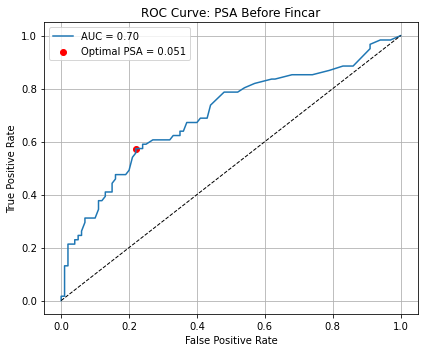

In [37]:
# Clean
data = df[['Fincar Result', 'PSA before fincar ']].dropna()
data = data[data['Fincar Result'].isin(['Success', 'Failure'])]

# Binary encoding: Failure = 1, Success = 0
data['event'] = (data['Fincar Result'] == 'Failure').astype(int)

# ROC computation
fpr, tpr, thresholds = roc_curve(data['event'], data['PSA before fincar '])
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]
auc = roc_auc_score(data['event'], data['PSA before fincar '])

print(f"Optimal PSA Threshold: {optimal_threshold:.3f}")
print(f"Sensitivity (TPR): {tpr[optimal_idx]:.2f}")
print(f"Specificity (1 - FPR): {1 - fpr[optimal_idx]:.2f}")
print(f"Youden Index: {youden_index[optimal_idx]:.2f}")
print(f"AUC: {auc:.2f}")

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label=f"Optimal PSA = {optimal_threshold:.3f}")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: PSA Before Fincar")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The ROC–AUC analysis demonstrated moderate discriminatory ability of PSA before 
Fincar administration. Higher PSA values were associated with an increased likelihood 
of treatment failure.

The identified PSA cutoff may be clinically useful for risk stratification, though 
it should be interpreted in the context of other clinical and pathological factors.


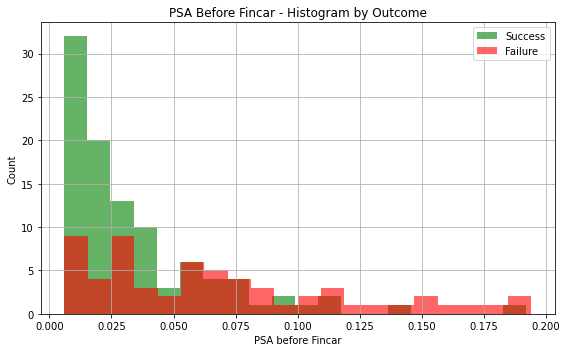

In [38]:

success_psa = data[data['Fincar Result'] == 'Success']['PSA before fincar '].dropna()
failure_psa = data[data['Fincar Result'] == 'Failure']['PSA before fincar '].dropna()

plt.figure(figsize=(8, 5))
plt.hist(success_psa, bins=20, alpha=0.6, label='Success', color='green')
plt.hist(failure_psa, bins=20, alpha=0.6, label='Failure', color='red')
plt.xlabel('PSA before Fincar')
plt.ylabel('Count')
plt.title('PSA Before Fincar - Histogram by Outcome')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [45]:

RED = '\033[91m'
GREEN = '\033[92m'
RESET = '\033[0m'

# Filter only success cases
success_df2 = df[df['Fincar Result'] == 'Success']

# Count of PSA values > 0.051
greater_count = (success_df2['PSA before fincar '] > 0.051).sum()

# Count of PSA values <= 0.051
less_equal_count = (success_df2['PSA before fincar '] <= 0.051).sum()

print(f"{RED}PSA before fincar > 0.051: {greater_count}{RESET}")
print(f"{GREEN}PSA before fincar <= 0.051: {less_equal_count}{RESET}")


PSA before fincar > 0.051: 22
PSA before fincar <= 0.051: 78


In [46]:

RED = '\033[91m'
GREEN = '\033[92m'
RESET = '\033[0m'

# Filter to only failure cases
failure_df2 = df[df['Fincar Result'] == 'Failure']

# Count of PSA values > 0.051
greater_count = (failure_df2['PSA before fincar '] > 0.051).sum()

# Count of PSA values <= 0.051
less_equal_count = (failure_df2['PSA before fincar '] <= 0.051).sum()

print(f"{RED}PSA before fincar > 0.051: {greater_count}{RESET}")
print(f"{GREEN}PSA before fincar <= 0.051: {less_equal_count}{RESET}")

PSA before fincar > 0.051: 34
PSA before fincar <= 0.051: 27


In [56]:
# Filter Success group
success_group = df[df['Fincar Result'] == 'Success']

# Calculate mean follow-up, min, and max
mean_followup = success_group['survival_time'].mean()
min_followup = success_group['survival_time'].min()
max_followup = success_group['survival_time'].max()

print(f"Mean follow-up: {mean_followup:.2f} months")
print(f"Range: {min_followup:.2f} – {max_followup:.2f} months")


Mean follow-up: 19.97 months
Range: 10.00 – 36.00 months


## Key Findings

- Kaplan–Meier analysis demonstrated that most failures occurred within the early 
  months following Fincar administration.
- Survival distributions varied across Gleason score categories.
- Pre-treatment PSA showed moderate ability to discriminate between Fincar success 
  and failure based on ROC–AUC analysis.


## Limitations

- Retrospective study design
- Limited sample size
- Single-center dataset
- Potential unmeasured confounding factors
- PSA threshold findings require external validation
